In [1]:
# Week 5 – End-to-End Vehicle Damage Severity Pipeline
# Objective: Integrate YOLOv8 detection + severity classification


In [4]:
# Step 1: Imports

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import tensorflow as tf

# Define severity class labels (adjust based on your model's training)
severity_labels = ["minor", "moderate", "severe"]  # or ["minor", "moderate", "severe"]

In [8]:
# Load YOLOv8 damage detector
YOLO_MODEL_PATH = "best_model.pt"
yolo_model = YOLO(YOLO_MODEL_PATH)

# Load severity classification model with memory optimization
SEVERITY_MODEL_PATH = "severity_model.h5"

# Clear memory before loading
import gc
gc.collect()

# Load model
try:
    severity_model = tf.keras.models.load_model(SEVERITY_MODEL_PATH)
    print("✅ Both models loaded successfully")
except MemoryError:
    print("❌ Not enough memory to load severity model!")
    print("Solutions:")
    print("1. Restart the kernel: Click 'Restart' button")
    print("2. Close other applications (browsers, etc.)")
    print("3. Use Task Manager to free up RAM")
    print("4. Try loading models one at a time")
    raise

✅ Both models loaded successfully


In [12]:
# Step 3: Load a single input image for full pipeline demo

IMAGE_PATH = "test/images/000165.jpg"   # <-- CHANGE to any existing image name
image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Image not found at {IMAGE_PATH}")

print("Input image loaded successfully")


Input image loaded successfully


In [13]:
# Step 4: Detect Damage Regions using YOLOv8

CONF_THRESHOLD = 0.3
boxes = []   # will store (x1, y1, x2, y2)

results = yolo_model(image, conf=CONF_THRESHOLD)

for r in results:
    if r.boxes is None:
        continue

    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # sanity check
        if x2 <= x1 or y2 <= y1:
            continue

        boxes.append((x1, y1, x2, y2))

print(f"Detected {len(boxes)} damage regions")



0: 448x640 1 glass_break, 17.8ms
Speed: 5.1ms preprocess, 17.8ms inference, 25.2ms postprocess per image at shape (1, 3, 448, 640)
Detected 1 damage regions


In [14]:
# Step 5: Predict Severity for each detected damage region

import gc

for (x1, y1, x2, y2) in boxes:

    # Crop damage region
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    # Preprocess for CNN
    crop_resized = cv2.resize(crop, (224, 224))
    crop_resized = crop_resized / 255.0
    crop_resized = np.expand_dims(crop_resized, axis=0)

    # Predict severity (verbose=0 to suppress output and reduce memory)
    pred = severity_model.predict(crop_resized, verbose=0)
    severity = severity_labels[np.argmax(pred)]

    # Draw bounding box
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw severity label
    cv2.putText(
        image,
        severity,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

# Clear memory after all predictions
gc.collect()

3751

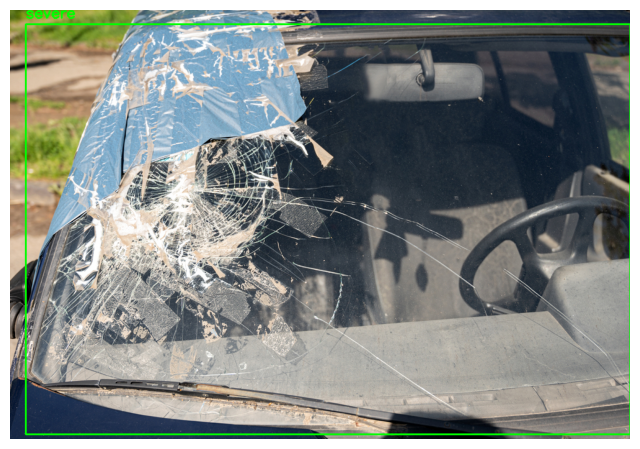

In [15]:
# Step 6: Visualization

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
# =========================
# Reflection
# =========================

# 1. What happens when detection is wrong?
# If the YOLOv8 detector fails to correctly localize damage regions,
# the downstream severity classifier is directly affected.
# - Missed detections lead to no severity prediction even when damage exists.
# - Incorrect or poorly localized bounding boxes produce bad crops,
#   which can confuse the CNN and result in wrong severity classification.
# Since the CNN only sees the cropped region, detection errors propagate
# through the entire pipeline.

# 2. Why is modular design useful here?
# The modular design separates damage detection (YOLOv8) and severity
# classification (CNN), allowing each component to be trained, evaluated,
# and improved independently.
# This makes debugging easier, enables reuse of models, and mirrors
# real-world deployment systems where models are chained together.
# Overall, modularity improves scalability, maintainability, and flexibility.
